___

<a href='https://oxiane-institut.com/'> <img src='../oxiane.jpg' /></a>
___
# Logistic Regression with Python

![Logistic Regression](https://pbs.twimg.com/media/GXWYK8UaEAAb2JX?format=jpg&name=4096x4096)

For this lecture, we will be working with the [Kaggle Titanic Data Set](https://www.kaggle.com/c/titanic). This is a very well-known dataset and often serves as a student's first step into machine learning!

We will try to predict a classification - survival or deceased.
Let's begin by understanding the implementation of logistic regression in Python for classification.

We will use a "semi-cleaned" version of the titanic dataset. If you are using the dataset hosted directly on Kaggle, you may need to do some additional cleaning not shown in this lecture notebook.

## Importing Libraries
Let's start by importing some libraries

In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
from sklearn.utils import check_random_state
import random

random.seed(42)
np.random.seed(42)
random_state = check_random_state(42)

## The Data

Let's start by reading the titanic_train.csv file into a pandas DataFrame.

In [243]:
train = pd.read_csv('titanic_train.csv')

In [244]:
train.shape

(891, 12)

In [245]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exploratory Data Analysis

Let's start an exploratory data analysis! We'll begin by checking for missing data!

## Missing Data

We can use seaborn to create a simple heatmap to see where we're missing data!

In [246]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

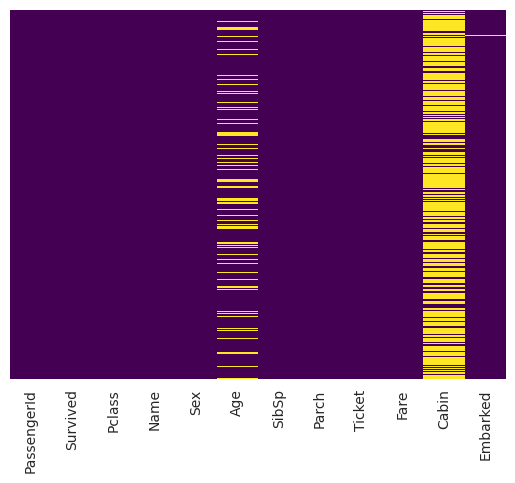

In [247]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

Approximately 20 percent of the age data is missing. The proportion of missing age is likely low enough to be reasonably replaced by some form of imputation. Looking at the Cabin column, it appears we're missing too much data to do something useful at a basic level. We'll probably drop it later, or replace it with another feature such as "Cabin known: 1 or 0".

Let's continue by visualizing even more data! Watch the video for full explanations of these plots, this code is just for reference.

<Axes: xlabel='Survived', ylabel='count'>

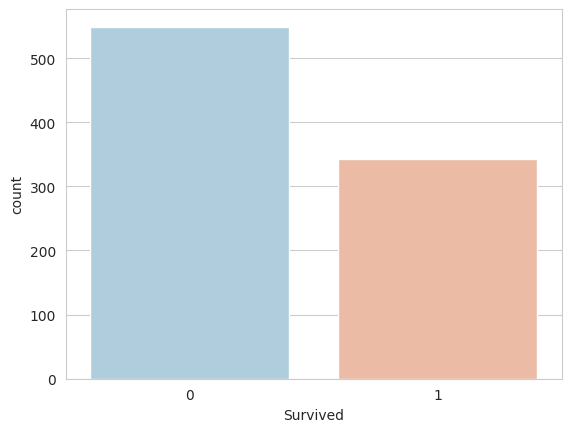

In [248]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Survived', data=train, palette='RdBu_r', legend=False)

<Axes: xlabel='Survived', ylabel='count'>

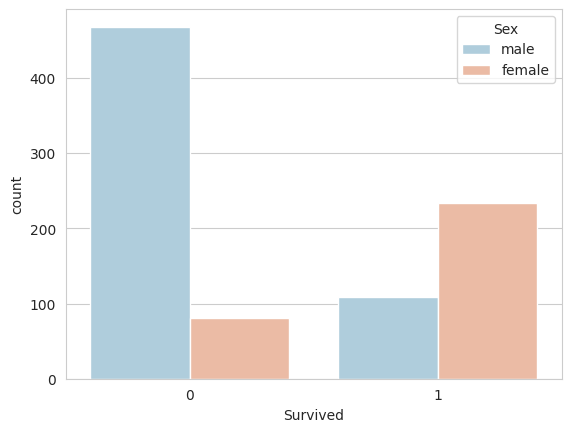

In [249]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=train, palette='RdBu_r')

<Axes: xlabel='Survived', ylabel='count'>

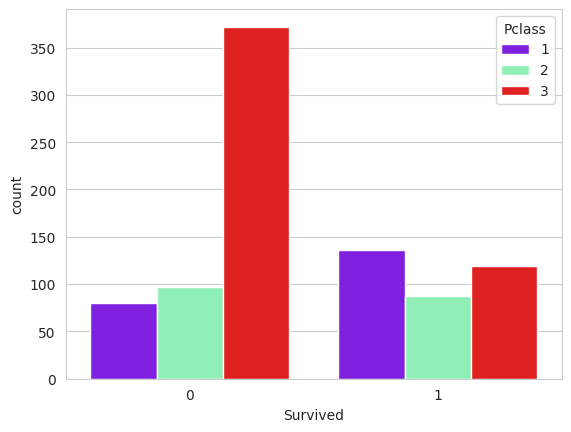

In [250]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Pclass',data=train,palette='rainbow')

Text(0.5, 0, 'Age')

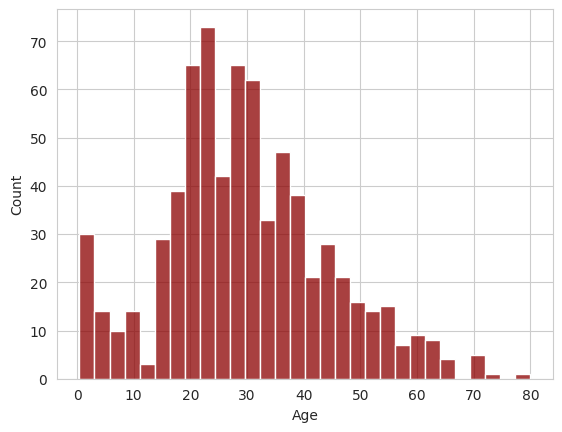

In [251]:
sns.histplot(data=train['Age'].dropna(), kde=False, color='darkred', bins=30)
plt.xlabel('Age')

<Axes: >

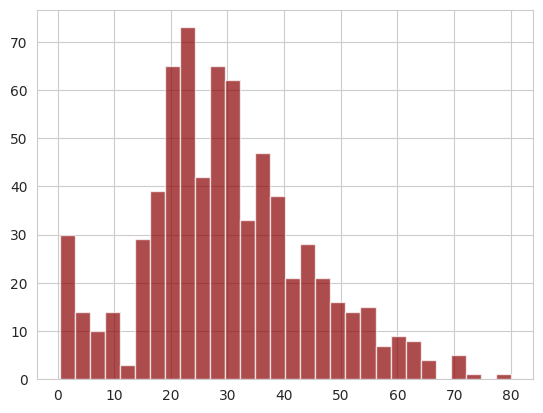

In [252]:
train['Age'].hist(bins=30,color='darkred',alpha=0.7)

<Axes: xlabel='SibSp', ylabel='count'>

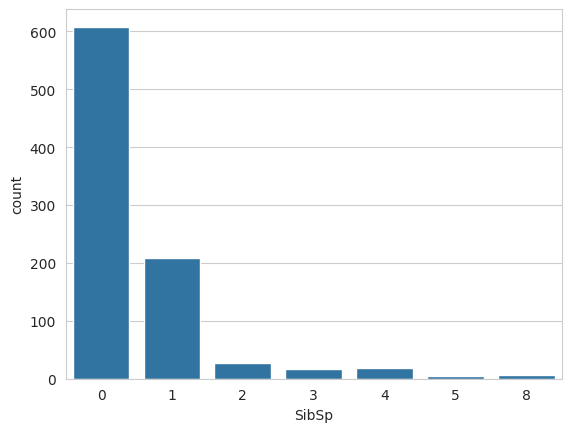

In [253]:
sns.countplot(x='SibSp',data=train)

<Axes: >

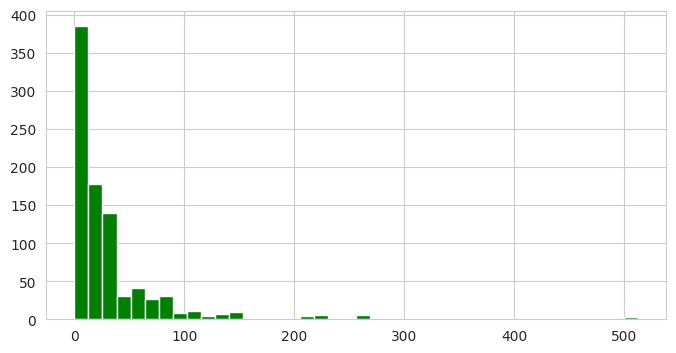

In [254]:
train['Fare'].hist(color='green',bins=40,figsize=(8,4))

___
## Data Cleaning

We want to fill in the missing age data instead of just dropping the missing age data rows. 

One way to do this is to fill in the mean age of all the passengers (imputation).

However, we can be smarter about this and check the average age by passenger class. For example:


<Axes: xlabel='Pclass', ylabel='Age'>

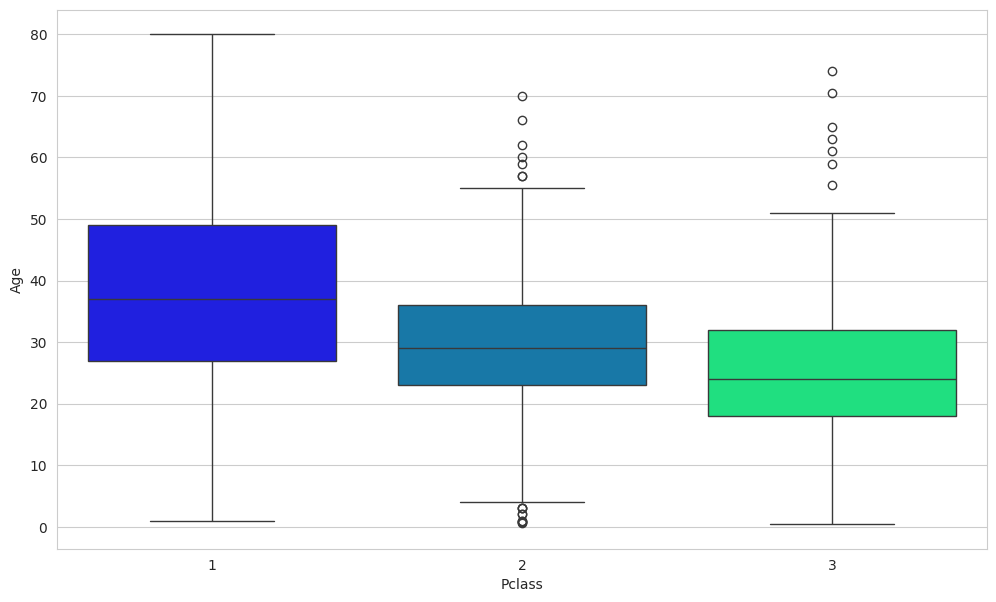

In [255]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Pclass', y='Age', data=train, hue='Pclass', palette='winter', legend=False)

In [256]:
train.groupby("Pclass").mean(numeric_only=True)

,PassengerId,Survived,Age,SibSp,Parch,Fare
Pclass,,,,,,
1,461.597222,0.629630,38.233441,0.416667,0.356481,84.154687
2,445.956522,0.472826,29.877630,0.402174,0.380435,20.662183
3,439.154786,0.242363,25.140620,0.615071,0.393075,13.675550


We can observe that the wealthier passengers from the upper classes tend to be older, which makes sense. We will use these average age values to impute based on the P class for age.

In [257]:
train.loc[train["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [258]:
def impute_age(cols):
    Age = cols.iloc[0]
    Pclass = cols.iloc[1]
    
    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age

Now, apply this function!

In [259]:
train['Age'] = train[['Age','Pclass']].apply(impute_age, axis=1)

Now, let's check this heatmap again!

<Axes: >

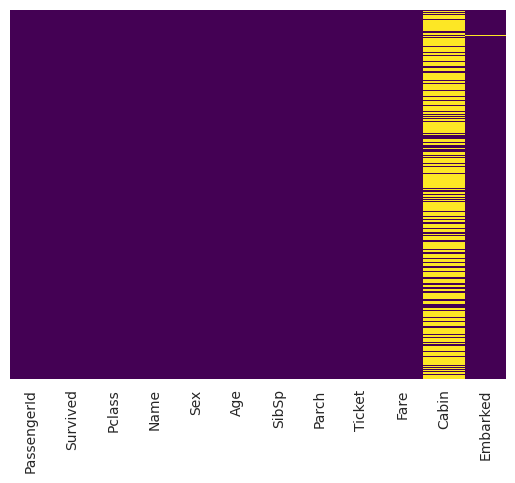

In [260]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

Great! Let's proceed and remove the Cabin column and the row in Embarked that is NaN.

In [261]:
train.drop('Cabin',axis=1,inplace=True)

In [262]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [263]:
train.dropna(inplace=True)

In [264]:
train.shape

(889, 11)

## Converting Categorical Features

We need to convert categorical features into dummy variables using pandas! Otherwise, our machine learning algorithm won't be able to directly incorporate these features as inputs.

In [265]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [266]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [267]:
sex = pd.get_dummies(train['Sex'], drop_first=True)
embark = pd.get_dummies(train["Embarked"], drop_first=True)

In [268]:
sex.head()

,male
0,True
1,False
2,False
3,False
4,True


In [269]:
embark.head()

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [270]:
train.drop(["PassengerId", "Sex", "Embarked", "Name", "Ticket"], axis=1, inplace=True)

In [271]:
train = pd.concat([train,sex,embark],axis=1)

In [272]:
train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


# Great! Our data is ready for our model!

# Building a Logistic Regression Model

Let's start by splitting our data into a training set and a test set (there's another test.csv file you can play with in case you want to use all of this data for training).

## Train-Test Split

In [273]:
from sklearn.model_selection import train_test_split

In [274]:
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived', axis=1), 
                                                    train['Survived'], test_size=0.30, 
                                                    random_state=101)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((622, 8), (267, 8), (622,), (267,))

## Training et Predicting

In [275]:
from sklearn.linear_model import LogisticRegression

In [276]:
logmodel = LogisticRegression(max_iter=1000)  # Increase max_iter to address convergence warning
logmodel.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [277]:
predictions = logmodel.predict(X_test)
predictions[10:]


array([1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1])

# Let's move on to evaluating our model!

## Evaluation

We can check the precision, recall, and f1-score using the classification report!

In [278]:
from sklearn.metrics import classification_report

In [281]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions)

array([[150,  13],
       [ 32,  72]])

In [ ]:
y_test.value_counts()

Survived
0    163
1    104
Name: count, dtype: int64

In [ ]:
(predictions == 0).sum() , (predictions == 1).sum()

(182, 85)

Here's an ASCII representation of the confusion matrix:
```
           Predicted
           0   |   1
         -------------
 Actual 0 | TN  |  FP
        1 | FN  |  TP
```
 Where:
- TP = True Positives
- TN = True Negatives
- FP = False Positives
- FN = False Negatives


In [282]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87       163
           1       0.85      0.69      0.76       104

    accuracy                           0.83       267
   macro avg       0.84      0.81      0.82       267
weighted avg       0.83      0.83      0.83       267



 - Classification problem uses metrics like:
    - precision:
        - How often are we correct in our positive prediction?
        - (TP) / (TP + FP)
    - recall:
        -  How often did we wrongly classify something as not true (= false)?
        - (TP) / (TP + FN)
    - accuracy:
        - Accuracy is how well the model performs
        - (TP + TN) / (TP + TN + FP + FN) 
    - f1_score:
        - Utilize the precision and recall to create a test’s accuracy through the “harmonic mean”.
        - It focuses on the on the left-bottom to right-top diagonal in the Confusion Matrix.
        - 2 * ((Precision * Recall) / (Precision + Recall))

Not bad! You might want to explore other feature engineering techniques and the other titanic_text.csv file. Here are some suggestions for feature engineering:

* Try extracting the title (Dr., Mr., Mrs., etc.) from the name as a feature
* Perhaps the cabin letter could be a feature
* Is there any information you can extract from the ticket?

In [283]:
pd.read_csv('titanic_train.csv').tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [284]:
# Optionally, we could also scale the data to help with convergence
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Min of 0 and max of 1
# MinMaxScaler()

# Mean of 0 and std of 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled[:5]

array([[ 0.82581213, -0.8594801 , -0.48408036, -0.46636808, -0.48186308,
        -1.33296126, -0.30519808,  0.61327497],
       [-0.36320441, -0.8594801 , -0.48408036,  0.76801892, -0.18433094,
        -1.33296126, -0.30519808,  0.61327497],
       [ 0.82581213, -0.23833011, -0.48408036, -0.46636808, -0.47893173,
        -1.33296126, -0.30519808,  0.61327497],
       [-1.55222095,  0.14988864,  0.43953309, -0.46636808,  0.48010864,
         0.75020935, -0.30519808,  0.61327497],
       [ 0.82581213, -0.39361761, -0.48408036, -0.46636808, -0.48235164,
         0.75020935,  3.27656055, -1.63058993]])

In [285]:
X_test.head()

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
511,3,24.0,0,0,8.05,True,False,True
613,3,24.0,0,0,7.75,True,True,False
615,2,24.0,1,2,65.00,False,False,True
337,1,41.0,0,0,134.50,False,False,False
718,3,24.0,0,0,15.50,True,True,False


In [286]:
X_test_scaled = scaler.transform(X_test)

In [287]:
X_test_scaled[:5]

array([[ 0.82581213, -0.39361761, -0.48408036, -0.46636808, -0.47648894,
         0.75020935, -0.30519808,  0.61327497],
       [ 0.82581213, -0.39361761, -0.48408036, -0.46636808, -0.48235164,
         0.75020935,  3.27656055, -1.63058993],
       [-0.36320441, -0.39361761,  0.43953309,  2.00240591,  0.63644736,
        -1.33296126, -0.30519808,  0.61327497],
       [-1.55222095,  0.92632612, -0.48408036, -0.46636808,  1.99464003,
        -1.33296126, -0.30519808, -1.63058993],
       [ 0.82581213, -0.39361761, -0.48408036, -0.46636808, -0.3308985 ,
         0.75020935,  3.27656055, -1.63058993]])

In [288]:
logmodel = LogisticRegression(
    max_iter=1000
)  # Increase max_iter to address convergence warning
logmodel.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [289]:
predictions = logmodel.predict(X_test_scaled)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87       163
           1       0.85      0.68      0.76       104

    accuracy                           0.83       267
   macro avg       0.83      0.80      0.81       267
weighted avg       0.83      0.83      0.82       267

